In [1]:
%load_ext autoreload
%autoreload 2

# `import`

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

from sb3_contrib import MaskablePPO

from medical_rl.libs.envs import get_env

from dice_rl_TU_Vienna.environment import test_env
from dice_rl_TU_Vienna.wrappers import AbsorbingWrapper, LoopingWrapper
from dice_rl_TU_Vienna.latex import latex_labels
from dice_rl_TU_Vienna.plot.general import plot_histogram
from dice_rl_TU_Vienna.plot.tabular import plot

from dice_rl_TU_Vienna.estimators.get import get_pv_s
from dice_rl_TU_Vienna.estimators.onpolicy import OnPE
from dice_rl_TU_Vienna.estimators.tabular.test import test_auxiliary_estimates
from dice_rl_TU_Vienna.estimators.tabular.importance_sampling   import IS
from dice_rl_TU_Vienna.estimators.tabular.tabular_vafe          import TabularVafe
from dice_rl_TU_Vienna.estimators.tabular.tabular_dice          import TabularDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice     import TabularDualDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice import TabularGradientDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_OffPE         import AuxiliaryEstimates

from dice_rl_TU_Vienna.utils.general import iterate_print
from dice_rl_TU_Vienna.utils.os import os_path_join
from dice_rl_TU_Vienna.utils.json import json_get_id
from dice_rl_TU_Vienna.utils.pandas import head_by_id

from plugins.sepsis.bologheanu.tabular.config import *

/Users/richardweiss/Documents/.venvs/dice_rl_TU_Vienna/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
pd.set_option("display.max_rows", 100)

# Prepare

In [4]:
id_policy["tabular"] = { # type: ignore
    name: json_get_id(
        file_path=os.path.join(dir_clustering, "policy.json"),
        dictionary={
            "seed": seed,
            "total_timesteps": total_timesteps[name],
            "model_type": "MaskablePPO",
        }
    )
        for name in names
            if name != "original"
}

dir_policy["tabular"] = {
    name: os_path_join(dir_clustering, id_policy["tabular"][name])
        for name in names
            if name != "original"
}

In [5]:
id_dataset["tabular"] = {}

name = "original"
id_dataset["tabular"][name] = json_get_id(
        file_path=os.path.join(dir_clustering, "dataset.json"),
        dictionary={
            "evaluation_policy": {
                "id": id_policy["tabular"]["evaluation"] # type: ignore
            }
        }
    )

for name in names:
    if name == "original": continue

    id_dataset["tabular"][name] = json_get_id(
        file_path=os.path.join(dir_clustering, id_policy["tabular"][name], "dataset.json"), # type: ignore
        dictionary={
            "n_trajectories": n_trajectories,
            "max_trajectory_length": max_trajectory_length,
            "seed": seed,
            "evaluation_policy": {
                "id": id_policy["tabular"]["evaluation"] # type: ignore
            }
        }
    )

dir_dataset["tabular"] = {
    name: os_path_join(
        dir_clustering,
        id_policy["tabular"].get(name, None), # type: ignore
        id_dataset["tabular"][name],
    )
        for name in names
}

In [6]:
train_test_clustered = {
    label: pd.read_parquet( os.path.join(dir_clustering, f"{label}.parquet") )
        for label in labels
}

In [7]:
env = { label: {} for label in labels }
action_mask = {}

for label in labels:
    x, y = get_env(
        n_clusters=n_clusters,
        data_clustered=train_test_clustered[label],
    )

    env[label] = {
        "": x,
        "absorbing": AbsorbingWrapper(x),
        "looping": LoopingWrapper(x),
    }
    action_mask[label] = y

In [36]:
model = {
    name: MaskablePPO.load(
        os.path.join(dir_policy["tabular"][name], "policy.zip")
    )
        for name in names
            if name != "original"
}

def get_act_(name, obs):
    with warnings.catch_warnings(action="ignore", category=UserWarning):
        act, _ = model[name].predict(obs, action_masks=action_mask["test"][obs]) # type: ignore
        act = int(act)
        return act

get_act_exploratory = lambda obs: get_act_("exploratory", obs)
get_act_evaluation  = lambda obs: get_act_("evaluation",  obs)

get_act = {
    "exploratory": get_act_exploratory,
    "evaluation": get_act_evaluation,
}

dir_policy["tabular"] = {
    name: os_path_join(dir_clustering, id_policy["tabular"][name]) # type: ignore
        for name in names
            if name != "original"
}

In [9]:
dataset = {
    name: pd.read_parquet(
        os_path_join(dir_dataset["tabular"][name], "dataset.parquet"),
    )
        for name in iterate_print(names, "name")
}

name=original
name=exploratory
name=evaluation


In [10]:
auxiliary_estimates = {
    name: AuxiliaryEstimates(
        dataset[name],
        n_obs, n_act,
        dir_dataset["tabular"][name],
        verbosity=1,
    )
        for name in iterate_print(names, "name")
}

name=original
trying to load auxiliary estimates from data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:36:57.598315
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:36:57.598315/d0_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:36:57.598315/dD_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:36:57.598315/P_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:36:57.598315/r_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:36:57.598315/n.npy
name=exploratory
trying to load auxiliary estimates from data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-04-04T14:16:14.383206/2025-04-04T14:37:38.614841
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.6

In [11]:
estimators = { name: {} for name in names }

print("OnPE")
label = "OnPE"
for name in iterate_print(names, "name"):
    estimators[name][label] = OnPE(dataset[name])

print("IS")
label = "IS"
for name in names[:-1]:
    estimators[name][label] = IS(dataset[name])

print("DICE")
for name in iterate_print(names, "name"):
    for estimator_type in [
        TabularVafe, TabularDice, TabularDualDice, TabularGradientDice, ]:

        estimator = estimator_type(
            dataset[name],
            n_obs,
            n_act,
            dir_dataset["tabular"][name],
            verbosity=1,
            auxiliary_estimates=auxiliary_estimates[name],
        )

        estimators[name][estimator.__name__] = estimator

OnPE
name=original
name=exploratory
name=evaluation
IS
DICE
name=original
name=exploratory
name=evaluation


In [12]:
estimators

{'original': {'OnPE': <dice_rl_TU_Vienna.estimators.onpolicy.OnPE at 0x324d04c90>,
  'IS': <dice_rl_TU_Vienna.estimators.tabular.importance_sampling.IS at 0x324d07b90>,
  'TabularVafe': <dice_rl_TU_Vienna.estimators.tabular.tabular_vafe.TabularVafe at 0x324d191d0>,
  'TabularDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dice.TabularDice at 0x31fa8ae90>,
  'TabularDualDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice.TabularDualDice at 0x324c91fd0>,
  'TabularGradientDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice.TabularGradientDice at 0x324d1ad50>},
 'exploratory': {'OnPE': <dice_rl_TU_Vienna.estimators.onpolicy.OnPE at 0x31eadcb90>,
  'IS': <dice_rl_TU_Vienna.estimators.tabular.importance_sampling.IS at 0x324896f10>,
  'TabularVafe': <dice_rl_TU_Vienna.estimators.tabular.tabular_vafe.TabularVafe at 0x324cdb650>,
  'TabularDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dice.TabularDice at 0x324d1ae50>,
  'TabularDualDice': <dice_rl_TU_Vienn

# `get_pvs`

In [13]:
pvs = { name: {} for name in names }

In [14]:
for name in iterate_print(names, "name"):
    label = "OnPE"

    print(label)
    pvs[name][label] = get_pv_s(
        estimator_s=estimators[name][label],
        gamma_s=gammas,
    )

name=original
OnPE
name=exploratory
OnPE
name=evaluation
OnPE


In [15]:
for name in iterate_print(names, "name"):
    if name == "evaluation": continue

    label = "IS"

    pvs[name][label] = {}

    print(label)
    for weighted in [False, True]:
        print(f"{weighted=}")
        pvs[name][label][weighted] = get_pv_s(
            estimator_s=estimators[name][label],
            gamma_s=gammas,
            weighted=weighted,
        )

name=original
IS
weighted=False
weighted=True
name=exploratory
IS
weighted=False
weighted=True
name=evaluation


In [16]:
for name in iterate_print(names, "name"):
    label = "TabularVafe"

    print(label)
    pvs[name][label] = get_pv_s(
        estimator_s=estimators[name][label],
        gamma_s=gammas,
        projected=projected, weighted=None,
        modified=modified, lamda=lamda,
    )

    for label in [
        "TabularDice", "TabularDualDice", "TabularGradientDice"]:

        print(label)
        pvs[name][label] = {}

        for weighted in [False, True]:
            print(f"{weighted=}")
            pvs[name][label][weighted] = get_pv_s(
                estimator_s=estimators[name][label],
                gamma_s=gammas,
                projected=projected, weighted=weighted,
                modified=modified, lamda=lamda,
            )

name=original
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True
name=exploratory
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True
name=evaluation
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True


In [17]:
pvs

{'original': {'OnPE': array([1.37285920e-02, 9.15364298e-03, 5.86716686e-03, 3.62124270e-03,
         2.16593946e-03, 1.26588052e-03, 7.28512731e-04, 4.15244523e-04,
         2.35329299e-04, 1.32921756e-04, 7.49347854e-05, 4.21985379e-05,
         2.37488958e-05, 1.33609780e-05, 7.51532711e-06, 4.22677925e-06,
         2.37708253e-06]),
  'IS': {False: array([9.42396291e+14, 1.30631206e+15, 1.19804360e+15, 8.82204110e+14,
          5.76360963e+14, 3.52446149e+14, 2.07725914e+14, 1.19933126e+14,
          6.84494772e+13, 3.88136371e+13, 2.19288604e+13, 1.23639820e+13,
          6.96306835e+12, 3.91887873e+12, 2.20477825e+12, 1.24016400e+12,
          6.97498604e+11]),
   True: array([1.35085163e-02, 1.87249652e-02, 1.71730212e-02, 1.26457083e-02,
          8.26168517e-03, 5.05204084e-03, 2.97758907e-03, 1.71914789e-03,
          9.81169904e-04, 5.56363235e-04, 3.14333122e-04, 1.77228045e-04,
          9.98101575e-05, 5.61740721e-05, 3.16037778e-05, 1.77767844e-05,
          9.99809883e-

In [18]:
pv = { name: {} for name in names }

In [19]:
for name in iterate_print(names, "name"):
    label = "OnPE"

    pv[name][label] = get_pv_s(
        estimator_s=estimators[name]["OnPE"],
        gamma_s=1.0,
        scale=False,
    )

name=original
name=exploratory
name=evaluation


In [20]:
for name in iterate_print(names, "name"):
    if name == "evaluation": continue

    label = "IS"

    pv[name][label] = {}

    for weighted in [False, True]:
        pv[name][label][weighted] = get_pv_s(
            estimator_s=estimators[name][label],
            gamma_s=1.0,
            weighted=weighted,
            scale=False,
        )

name=original
name=exploratory
name=evaluation


In [21]:
pv

{'original': {'OnPE': 0.2377326565143824,
  'IS': {False: 6.97631141566965e+16, True: 0.99999986608721}},
 'exploratory': {'OnPE': 0.3045,
  'IS': {False: 0.4405838168114867, True: 0.37430450461408465}},
 'evaluation': {'OnPE': 0.3659}}

# Plots

In [22]:
def plot_pvs_sepsis_bologheanu_tabular(name, weighted):

    plot_infos = []

    plot_infos += [
        {
            "x": 0.99,
            "label": "gamma=0.99",
            "color": "black",
            "marker": None,
        }
    ]

    plot_infos += [
        {
            "y": pv["evaluation"]["OnPE"],
            "label": None,
            "color": "grey",
            "marker": "^",
        },
    ]
    if name != "evaluation":
        plot_infos += [
            {
                "y": pv[name]["OnPE"],
                "label": None,
                "color": "lightgrey",
                "marker": "v",
            },
        ]
    if name != "evaluation":
        plot_infos += [
            {
                "y": pv[name]["IS"][weighted],
                "label": None,
                "color": "pink" if not weighted else "deeppink",
                "marker": "+" if not weighted else "x",
            },
        ]

    plot_infos += [
        {
            "x": gammas,
            "y": pvs["evaluation"]["OnPE"],
            "label": "OnPE evaluation",
            "color": "grey",
            "marker": "^",
        },
    ]
    if name != "evaluation":
        plot_infos += [
            {
                "x": gammas,
                "y": pvs[name]["OnPE"],
                "label": f"OnPE {name}",
                "color": "lightgrey",
                "marker": "v",
            },
        ]
    plot_infos += [
        {
            "x": gammas,
            "y": pvs[name]["TabularVafe"],
            "label": "TabularVafe",
            "color": "blue",
            "marker": "1",
        },
        {
            "x": gammas,
            "y": pvs[name]["TabularDice"][weighted],
            "label": "TabularDice",
            "color": "orange",
            "marker": "2",
        },
        {
            "x": gammas,
            "y": pvs[name]["TabularDualDice"][weighted],
            "label": "TabularDualDice",
            "color": "green",
            "marker": "3",
        },
        {
            "x": gammas,
            "y": pvs[name]["TabularGradientDice"][weighted],
            "label": f"TabularGradientDice, lamda={lamda}",
            "color": "red",
            "marker": "4",
        },
    ]
    if name != "evaluation":
        plot_infos += [
            {
                "x": gammas,
                "y": pvs[name]["IS"][weighted],
                "label":  "SIS"  if not weighted else "WIS",
                "color":  "pink" if not weighted else "deeppink",
                "marker": "+"    if not weighted else "x",
            }
        ]

    suptitle = f"Sepsis Bologheanu Tabular - {name} - PVs" + "\n" + f"{projected=}, {weighted=}"

    one_minus_gamma = True
    scale_pv = True

    xlabel = None
    ylabel = latex_labels["pv_scaled"]()

    xlim = None
    # ylim = [0.1, 0.4]
    ylim = [0, 1]

    scale_x = True
    scale_y = False

    legend = { "loc": "upper right", }

    dir = os.path.join(dir_images, "tabular")

    plot(
        plot_infos,
        suptitle,
        one_minus_gamma, scale_pv,
        xlabel, ylabel,
        xlim, ylim,
        scale_x, scale_y,
        legend, # type: ignore
        dir,
)

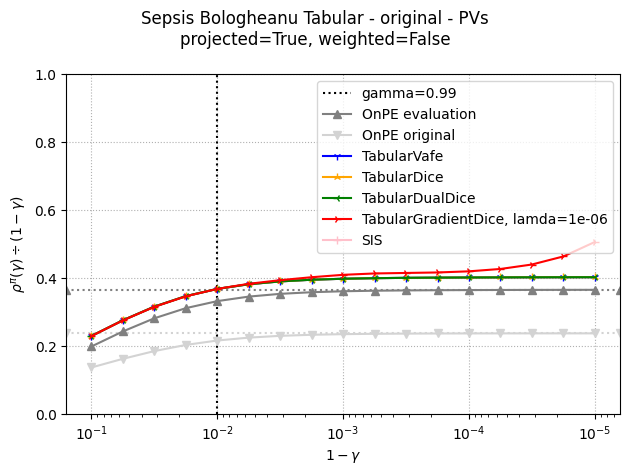

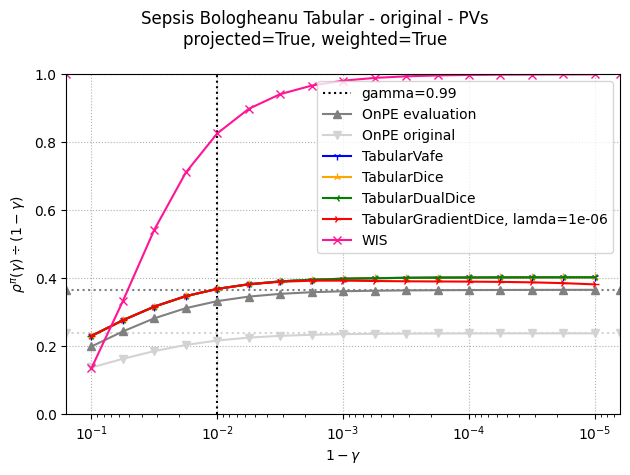

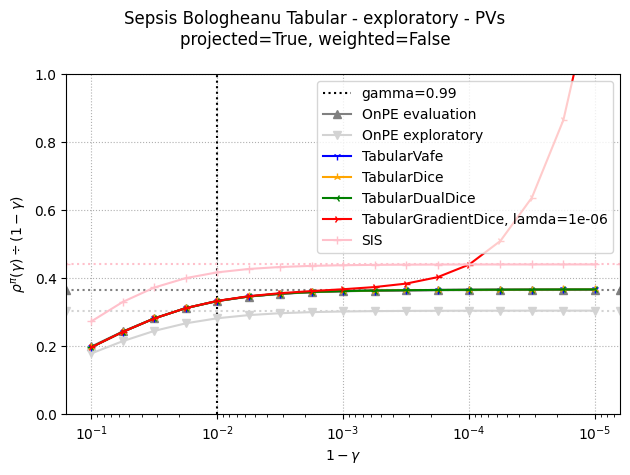

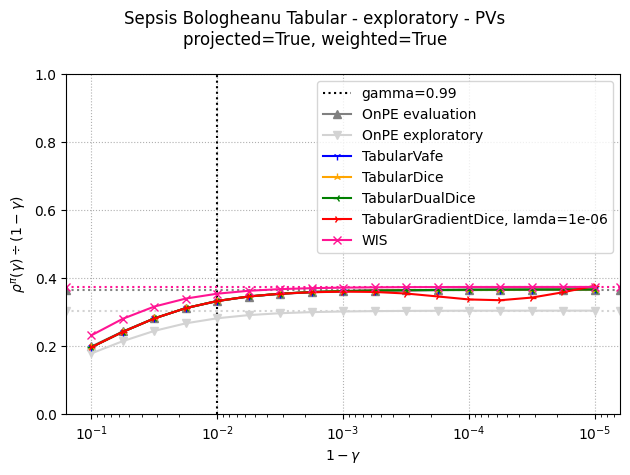

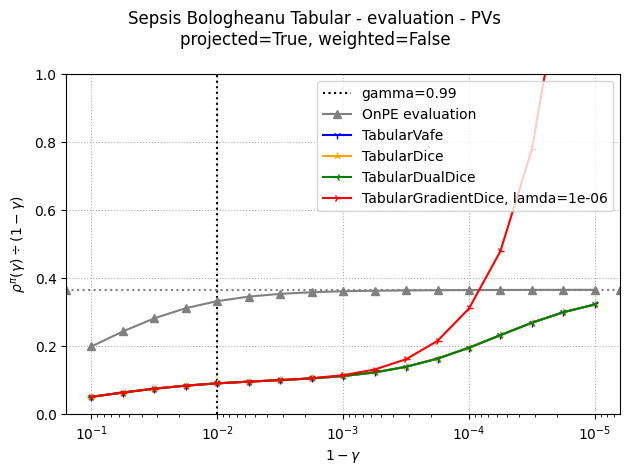

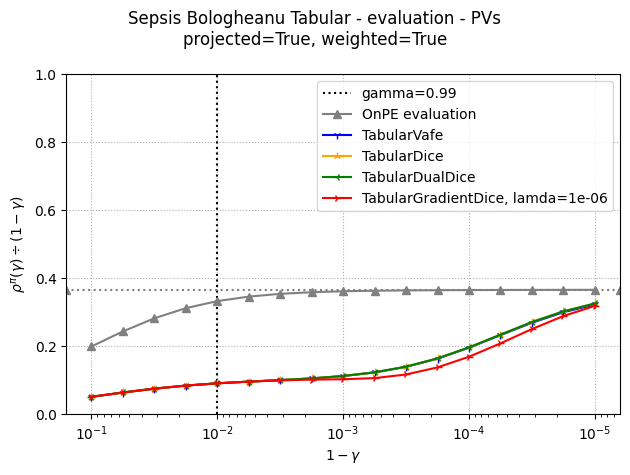

In [23]:
for name in names:
    for weighted in [False, True]:
        plot_pvs_sepsis_bologheanu_tabular(name, weighted)

# Supplementary

## Policy Ratios

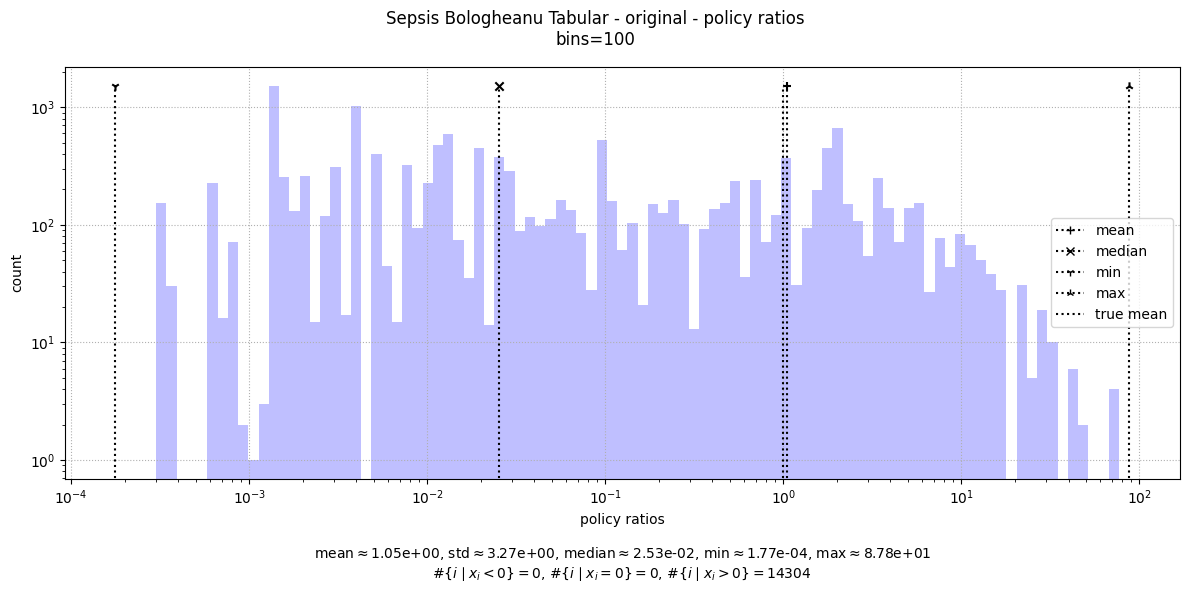

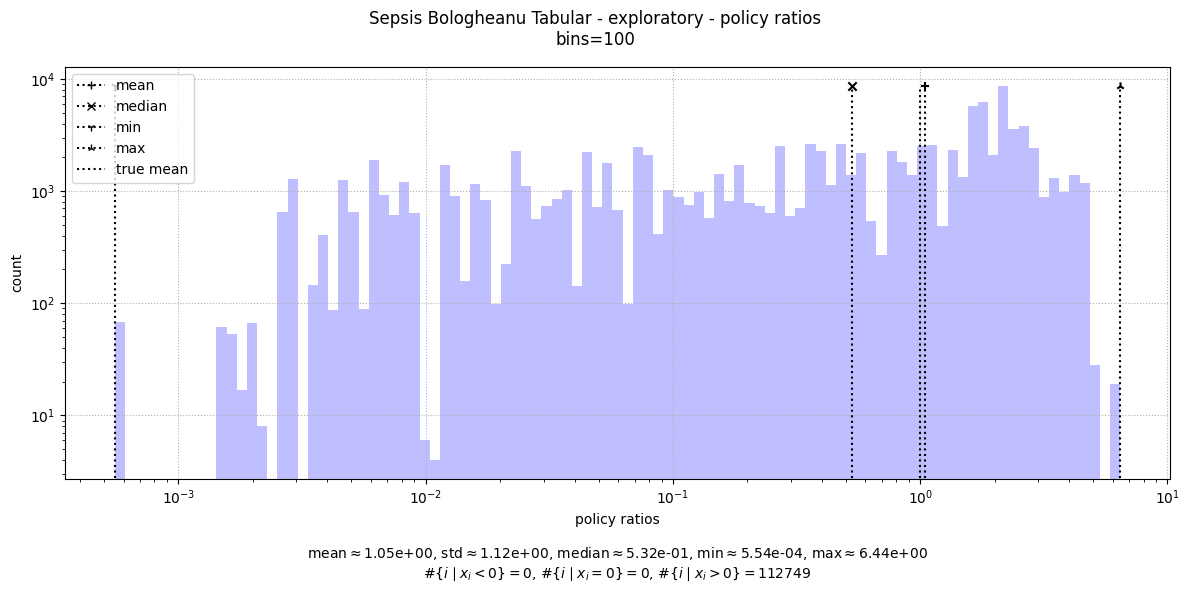

In [24]:
for name in names:
    if name == "evaluation": continue

    plot_histogram(
        data=estimators[name]["IS"].q,
        bins=100,
        suptitle=f"Sepsis Bologheanu Tabular - {name} - policy ratios", xlabel="policy ratios",
        xscale=True, yscale=True,
        true_mean=1,
        dir=os.path.join(dir_images, "tabular"),
    )

/Users/richardweiss/Documents/.venvs/dice_rl_TU_Vienna/lib/python3.11/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


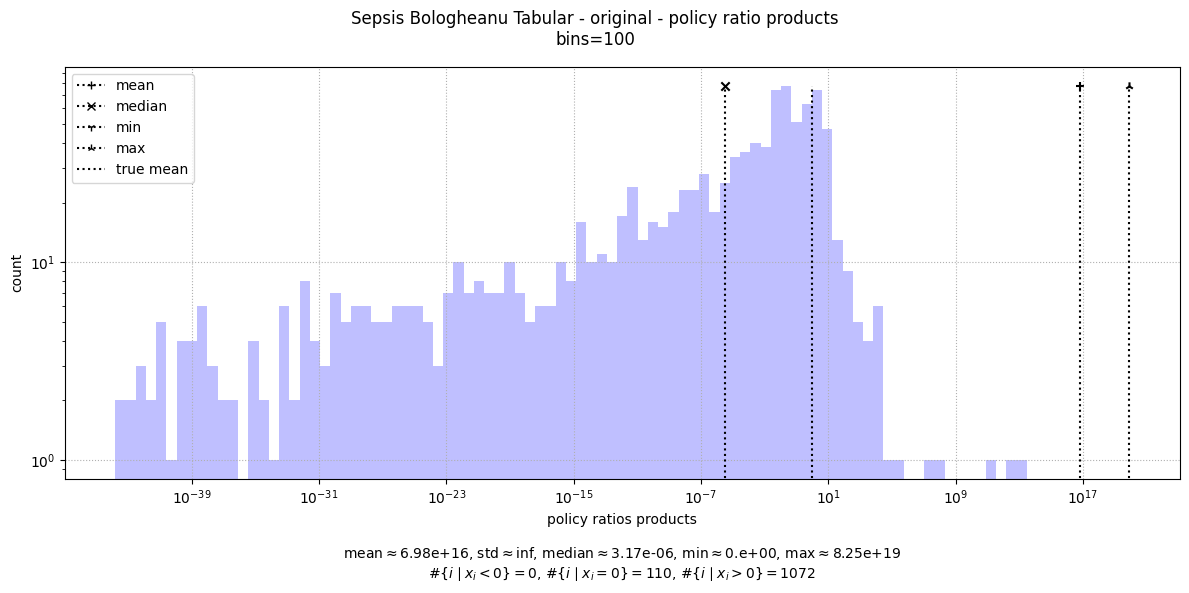

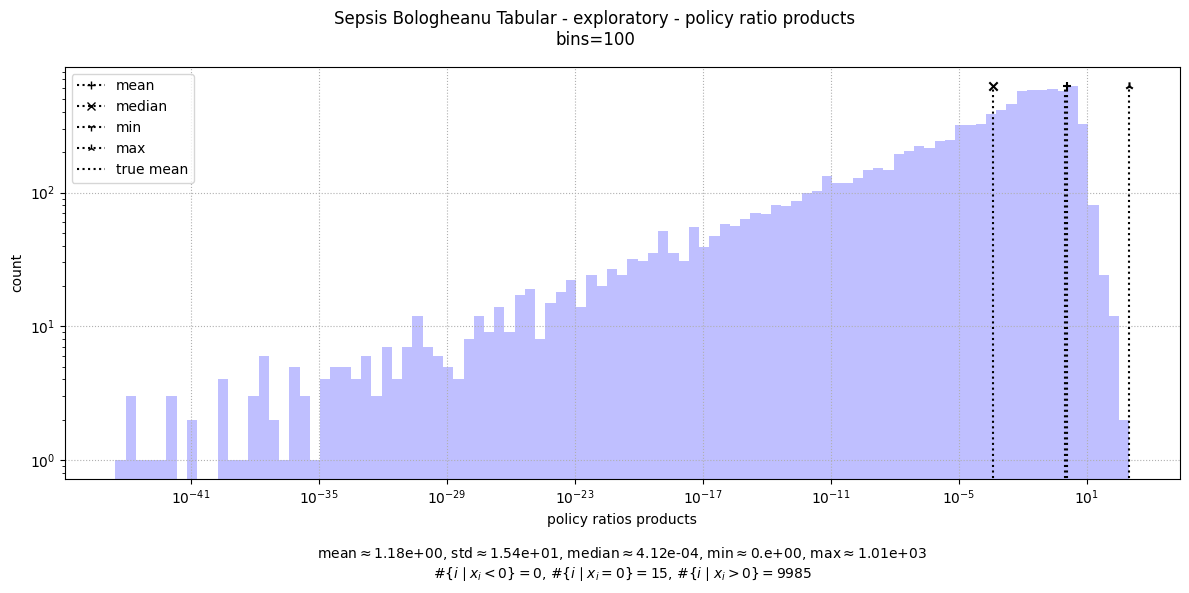

In [25]:
for name in names:
    if name == "evaluation": continue

    plot_histogram(
        data=estimators[name]["IS"].W,
        bins=100,
        suptitle=f"Sepsis Bologheanu Tabular - {name} - policy ratio products", xlabel="policy ratios products",
        xscale=True, yscale=True,
        true_mean=1,
        dir=os.path.join(dir_images, "tabular"),
    )

## `AuxiliaryEstimates`

In [26]:
def test_auxiliary_estimates_sepsis_bologheanu_tabular(name):
    test_auxiliary_estimates(
        auxiliary_estimates=auxiliary_estimates[name],
        title_prefix=f"Sepsis Bologheanu Tabular - {name}",
        dir=os.path.join(dir_images, "tabular", "auxiliary_estimates"),
    )

# (s, a) visited:
{'absolute': 636, 'relative': 0.4930232558139535}
# (s, a) not visited:
{'absolute': 654, 'relative': 0.5069767441860465}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 0
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 0

# ---------------------------------------------------------------- # 



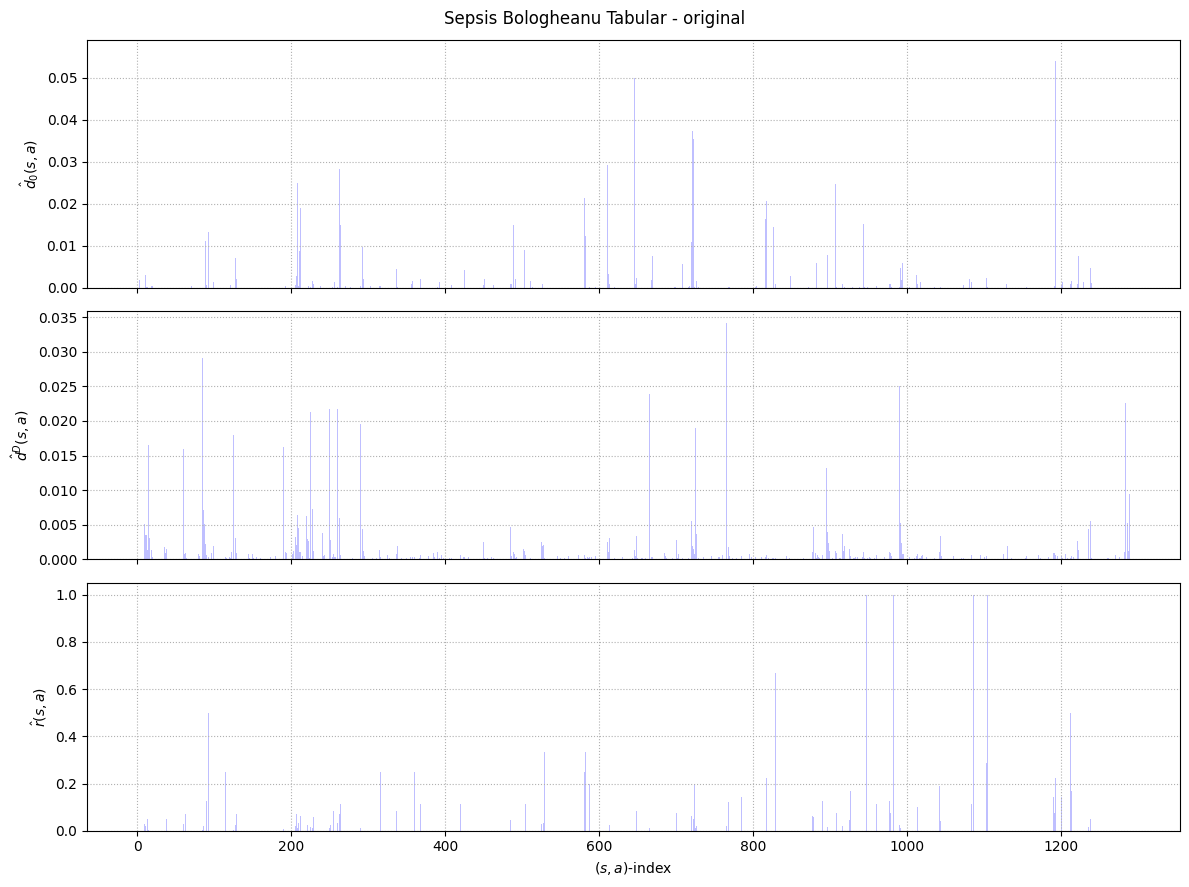

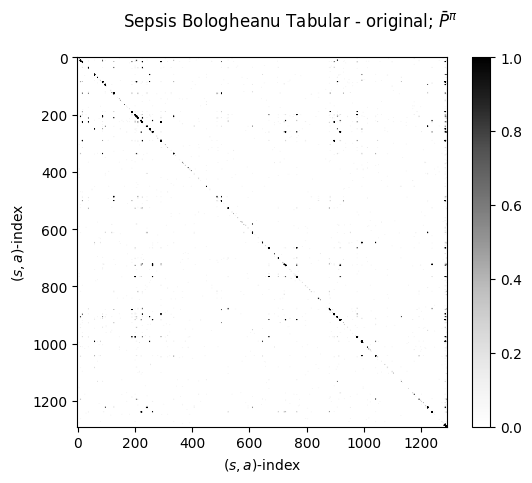

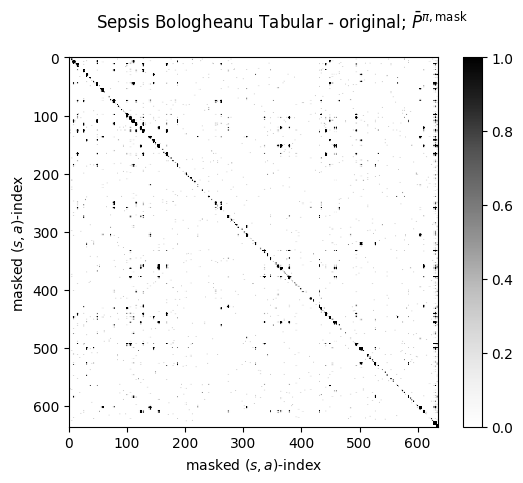

# ---------------------------------------------------------------- # 



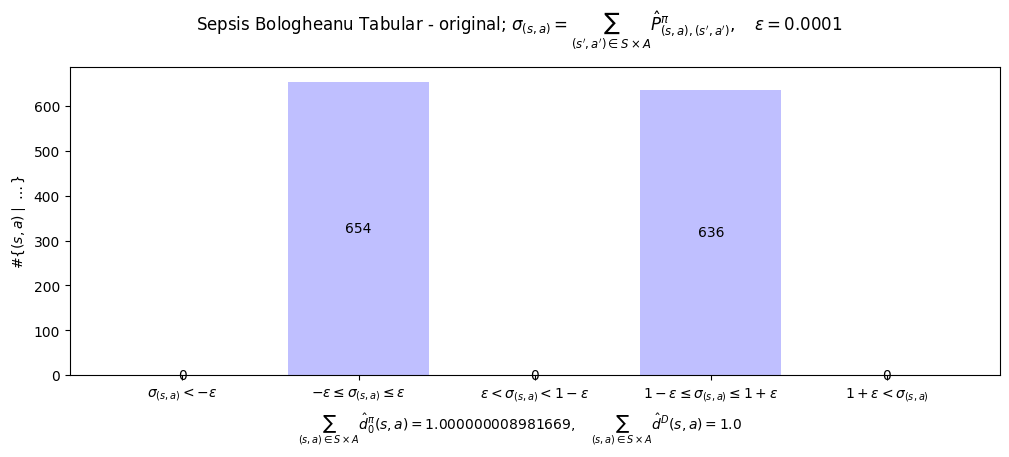

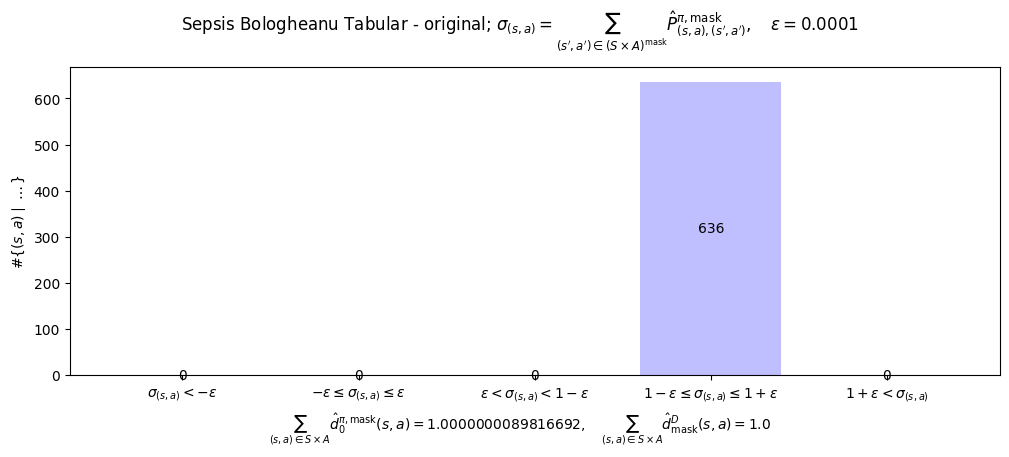

# ---------------------------------------------------------------- # 



In [27]:
test_auxiliary_estimates_sepsis_bologheanu_tabular("original")

# (s, a) visited:
{'absolute': 634, 'relative': 0.49147286821705427}
# (s, a) not visited:
{'absolute': 656, 'relative': 0.5085271317829457}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 4
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 0

# ---------------------------------------------------------------- # 



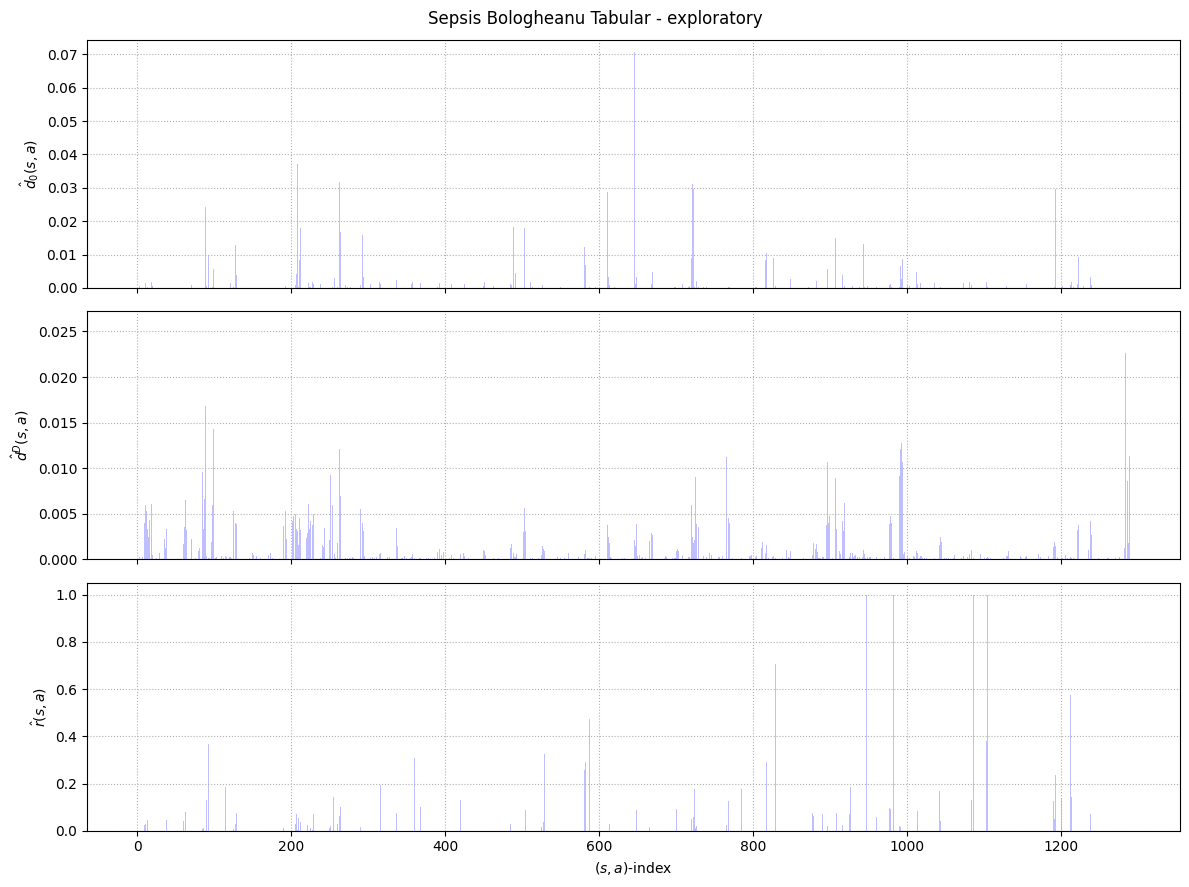

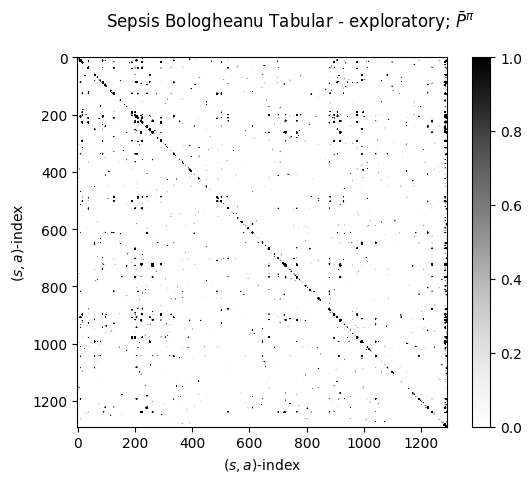

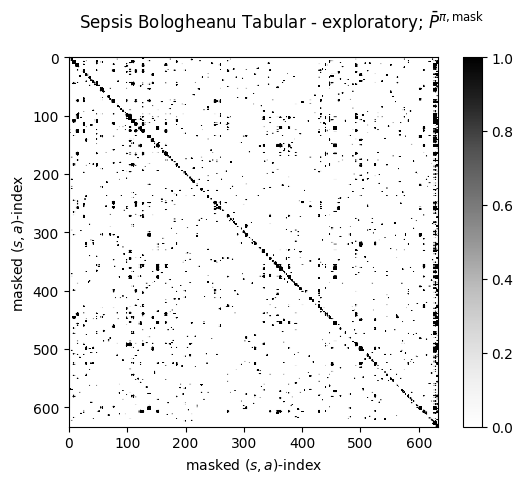

# ---------------------------------------------------------------- # 



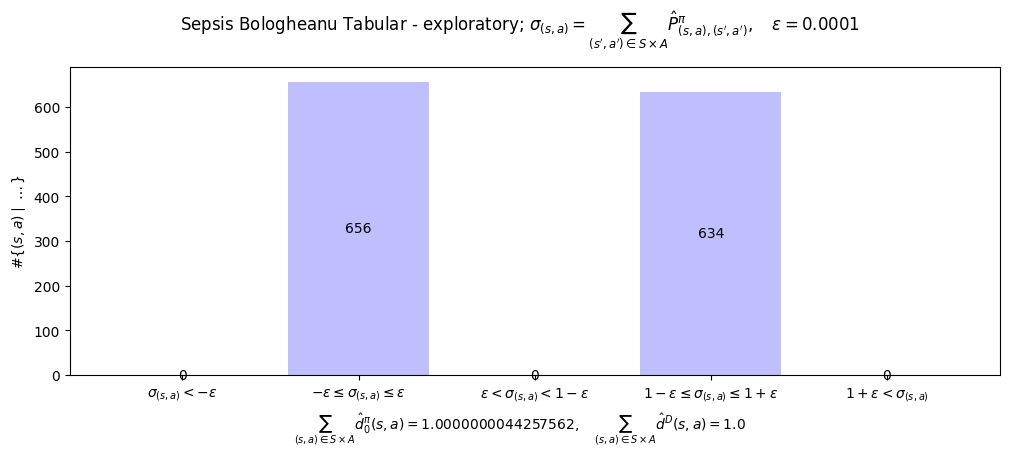

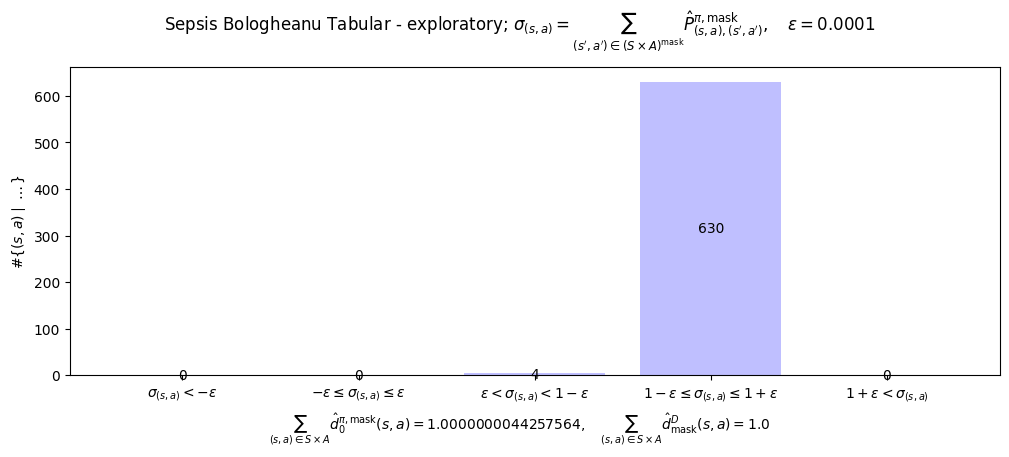

# ---------------------------------------------------------------- # 



In [28]:
test_auxiliary_estimates_sepsis_bologheanu_tabular("exploratory")

# (s, a) visited:
{'absolute': 551, 'relative': 0.42713178294573645}
# (s, a) not visited:
{'absolute': 739, 'relative': 0.5728682170542636}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 418
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 47

# ---------------------------------------------------------------- # 



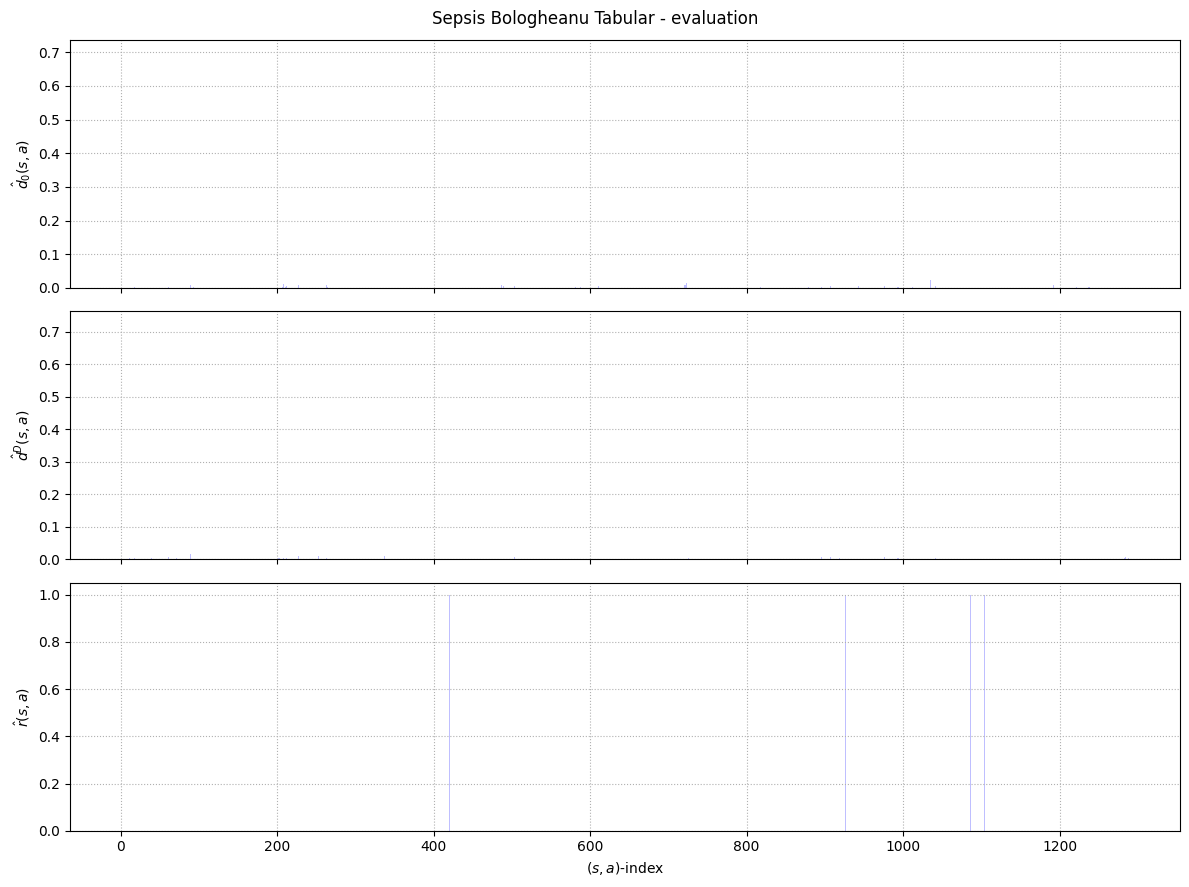

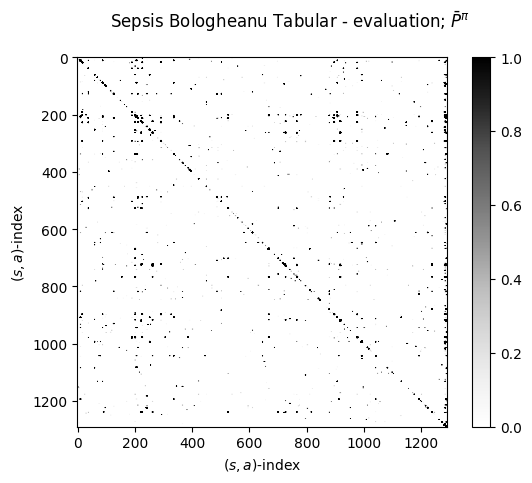

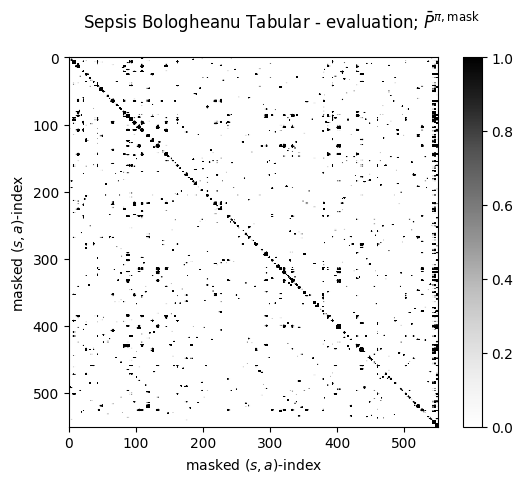

# ---------------------------------------------------------------- # 



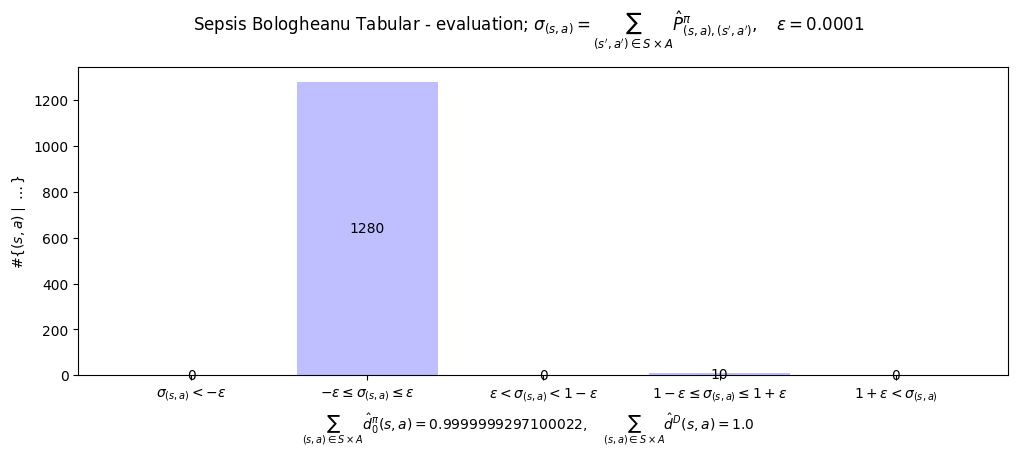

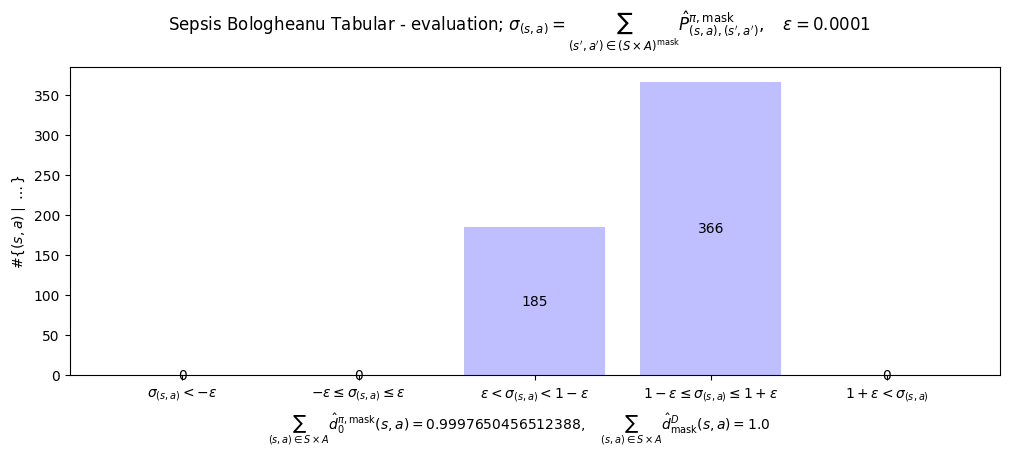

# ---------------------------------------------------------------- # 



In [29]:
test_auxiliary_estimates_sepsis_bologheanu_tabular("evaluation")

## Environments

In [30]:
np.mean(action_mask["train"] == action_mask["test"])

0.6410852713178294

In [35]:
env["test"][""]

<ActionMasker<CustomEnv instance>>

In [ ]:
test_env(
    env=env["test"][""],
    get_act=get_act["exploratory"],
    num_trajectory=1_000,
    verbosity=1,
)

100%|██████████| 1000/1000 [00:03<00:00, 302.61it/s]


{'distinct_absolute': {'mean': 5.22, 'std': 3.078571097116323},
 'distinct_relative': {'mean': 0.6176971681899807, 'std': 0.25277621345419193},
 'all': {'mean': 11.185, 'std': 9.794527808934946}}

In [38]:
test_env(
    env=env["test"][""],
    get_act=get_act["evaluation"],
    num_trajectory=1_000,
    verbosity=1,
)

100%|██████████| 1000/1000 [00:12<00:00, 78.83it/s] 


{'distinct_absolute': {'mean': 5.45, 'std': 3.5740033575809633},
 'distinct_relative': {'mean': 0.5855246037429043, 'std': 0.2692690618581132},
 'all': {'mean': 41.151, 'std': 539.6927146061914}}